# MSE802 Assessment 2 — Task 2: Qiskit Circuits

**Course:** MSE802 Quantum Computing  
**Runtime:** local Python 3.11 / Qiskit Aer, with Quokka validation  
**Learning outcomes:** LO1 and LO2


## 1. Scope and interpretation of the supplied diagram

The supplied diagram shows H on the upper qubit, X on the lower qubit, followed by a two-input block labelled `C`. In the context of the course material on controlled gates, this notebook interprets `C` as CNOT/CX: upper qubit q0 is the control and lower qubit q1 is the target. This explicit interpretation should be confirmed during peer/tutor review because the assessment diagram is not standard Qiskit notation.

The task has two parts: reproduce the supplied circuit and create an original OpenQASM 2 circuit using multiple qubits and gates. Both circuits are validated locally and executed on Quokka.


In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, qasm2
from qiskit.quantum_info import Statevector

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mse802 import AssessmentConfig, QuokkaClient, run_qasm_locally

config = AssessmentConfig.from_env()
SHOTS = config.shots
SEED = config.seed
RUN_QUOKKA = os.getenv("MSE802_RUN_QUOKKA", "0") == "1"
print(f"shots={SHOTS}, seed={SEED}, Quokka={config.quokka_qasm_url}")


shots=1024, seed=802, Quokka=https://quokka1.quokkacomputing.com/qsim/qasm


## 2. Part A - specified Qiskit circuit

The gates are applied in diagram order: H(q0), X(q1), then CX(q0, q1). A separate state-only circuit is used for exact statevector analysis before measurement is added.


In [2]:
specified_state_circuit = QuantumCircuit(2, name="specified_state")
specified_state_circuit.h(0)
specified_state_circuit.x(1)
specified_state_circuit.cx(0, 1)

specified_circuit = QuantumCircuit(2, 2, name="specified_measured")
specified_circuit.compose(specified_state_circuit, inplace=True)
specified_circuit.measure([0, 1], [0, 1])

print(specified_circuit.draw(output="text"))
operation_names = [instruction.operation.name for instruction in specified_circuit.data]
assert operation_names == ["h", "x", "cx", "measure", "measure"]


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     ├───┤┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ X ├─╫─┤M├
     └───┘└───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


Statevector in Qiskit |q1 q0> order: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


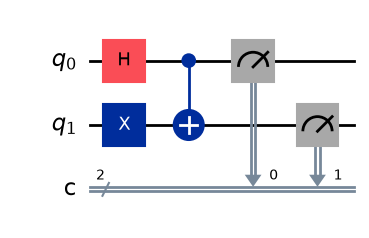

In [3]:
specified_statevector = Statevector.from_instruction(specified_state_circuit)
expected_statevector = np.array([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0], dtype=complex)
assert np.allclose(specified_statevector.data, expected_statevector, atol=1e-8)
print("Statevector in Qiskit |q1 q0> order:", specified_statevector.data)

circuit_figure = specified_circuit.draw(output="mpl", fold=-1)
circuit_figure.savefig("task2_specified_circuit.png", dpi=180, bbox_inches="tight")
display(circuit_figure)


The exact state is $(|01\rangle+|10\rangle)/\sqrt{2}$ in Qiskit's displayed bit order $|q_1q_0\rangle$. Therefore measurement should produce only `01` and `10`, approximately half of the shots each.


## 3. OpenQASM 2 export and local Aer validation


In [4]:
specified_standard_qasm = qasm2.dumps(specified_circuit)
specified_qasm_path = Path("task2_specified_standard.qasm")
specified_qasm_path.write_text(specified_standard_qasm, encoding="utf-8")

# Round-trip parsing confirms that the saved QASM is complete and valid.
round_trip_circuit = qasm2.loads(specified_standard_qasm)
assert [item.operation.name for item in round_trip_circuit.data] == operation_names
print(specified_standard_qasm)


OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
x q[1];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [5]:
specified_local_counts = run_qasm_locally(
    specified_standard_qasm, shots=SHOTS, seed=SEED
)
assert set(specified_local_counts) <= {"01", "10"}
assert sum(specified_local_counts.values()) == SHOTS
specified_local_probabilities = {
    label: specified_local_counts.get(label, 0) / SHOTS
    for label in ["00", "01", "10", "11"]
}
print("Aer counts:", specified_local_counts)
print("Aer probabilities:", specified_local_probabilities)


Aer counts: {'10': 500, '01': 524}
Aer probabilities: {'00': 0.0, '01': 0.51171875, '10': 0.48828125, '11': 0.0}


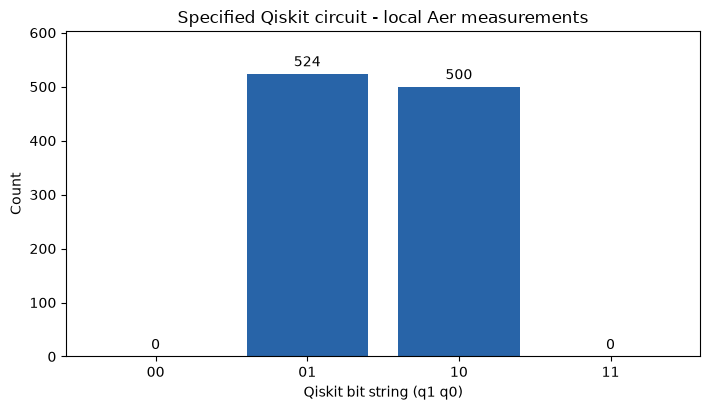

In [6]:
specified_labels = ["00", "01", "10", "11"]
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(
    specified_labels,
    [specified_local_counts.get(label, 0) for label in specified_labels],
    color="#2864A8",
)
ax.bar_label(bars, padding=3)
ax.set(
    title="Specified Qiskit circuit - local Aer measurements",
    xlabel="Qiskit bit string (q1 q0)",
    ylabel="Count",
)
ax.set_ylim(0, max(specified_local_counts.values()) * 1.15)
fig.tight_layout()
fig.savefig("task2_specified_local_histogram.png", dpi=180)
plt.show()


Qiskit prints classical bit 1 to the left of classical bit 0. Consequently, output `10` means q1=1 and q0=0, while `01` means q1=0 and q0=1. The H gate creates the two control branches. X initializes q1 to 1, and CX flips q1 only when q0=1, producing the anti-correlated state $(|01\rangle+|10\rangle)/\sqrt{2}$. The finite difference between the two counts is ordinary shot noise.


## 4. Part B - original OpenQASM circuit

The original circuit uses three qubits. H creates an equal superposition on q0; RY creates a tunable real-amplitude superposition on q1; X initializes q2 to one; CX gates propagate conditional relationships; RZ adds a relative phase; and the second H on q1 converts part of that phase information back into measurable amplitude. This is more expressive than a Bell-pair demonstration while remaining small enough to analyse and execute efficiently.


In [7]:
custom_standard_qasm = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
ry(1.0471975511965976) q[1];
x q[2];
cx q[0],q[1];
rz(0.7853981633974483) q[1];
h q[1];
cx q[1],q[2];
measure q -> c;
"""
custom_qasm_path = Path("task2_custom_standard.qasm")
custom_qasm_path.write_text(custom_standard_qasm, encoding="utf-8")

custom_circuit = qasm2.loads(custom_standard_qasm)
custom_operations = [item.operation.name for item in custom_circuit.data]
required_gates = {"h", "ry", "x", "cx", "rz", "measure"}
assert required_gates <= set(custom_operations)
assert custom_circuit.num_qubits == 3
print(custom_standard_qasm)
print(custom_circuit.draw(output="text"))


OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
ry(1.0471975511965976) q[1];
x q[2];
cx q[0],q[1];
rz(0.7853981633974483) q[1];
h q[1];
cx q[1],q[2];
measure q -> c;

        ┌───┐                   ┌─┐                
q_0: ───┤ H ├─────■─────────────┤M├────────────────
     ┌──┴───┴──┐┌─┴─┐┌─────────┐└╥┘┌───┐     ┌─┐   
q_1: ┤ Ry(π/3) ├┤ X ├┤ Rz(π/4) ├─╫─┤ H ├──■──┤M├───
     └──┬───┬──┘└───┘└─────────┘ ║ └───┘┌─┴─┐└╥┘┌─┐
q_2: ───┤ X ├────────────────────╫──────┤ X ├─╫─┤M├
        └───┘                    ║      └───┘ ║ └╥┘
c: 3/════════════════════════════╩════════════╩══╩═
                                 0            1  2 


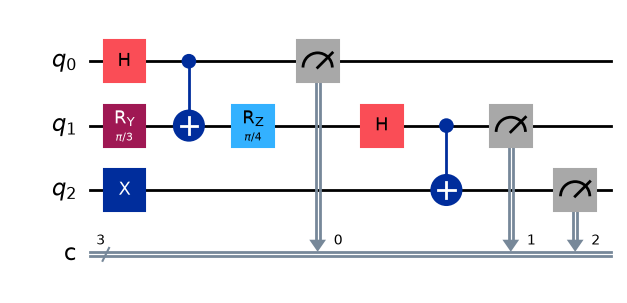

Custom-circuit Aer counts: {'010': 98, '011': 113, '100': 410, '101': 403}


In [8]:
custom_circuit_figure = custom_circuit.draw(output="mpl", fold=-1)
custom_circuit_figure.savefig("task2_custom_circuit.png", dpi=180, bbox_inches="tight")
display(custom_circuit_figure)

custom_local_counts = run_qasm_locally(custom_standard_qasm, shots=SHOTS, seed=SEED)
assert sum(custom_local_counts.values()) == SHOTS
print("Custom-circuit Aer counts:", dict(sorted(custom_local_counts.items())))


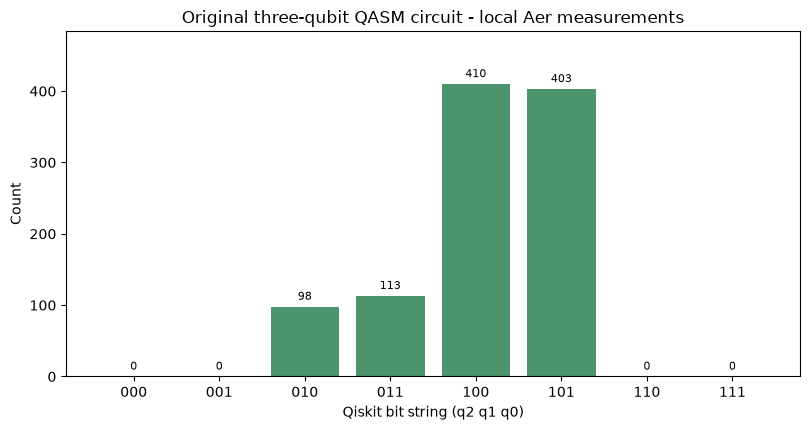

In [9]:
custom_labels = [f"{value:03b}" for value in range(8)]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.bar(
    custom_labels,
    [custom_local_counts.get(label, 0) for label in custom_labels],
    color="#4C956C",
)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set(
    title="Original three-qubit QASM circuit - local Aer measurements",
    xlabel="Qiskit bit string (q2 q1 q0)",
    ylabel="Count",
)
ax.set_ylim(0, max(custom_local_counts.values()) * 1.18)
fig.tight_layout()
fig.savefig("task2_custom_local_histogram.png", dpi=180)
plt.show()


## 5. Quokka executions and retained evidence


In [10]:
def make_quokka_compatible(qasm_source, qubit_count):
    """Adapt standard QASM to the register format used in course examples."""
    adapted = qasm_source.replace('include "qelib1.inc";', "")
    adapted = adapted.replace(
        f"creg c[{qubit_count}];",
        "\n".join(f"creg q{i}_out[1];" for i in range(qubit_count)),
    )
    adapted = adapted.replace(
        "measure q -> c;",
        "\n".join(
            f"measure q[{i}] -> q{i}_out[0];" for i in range(qubit_count)
        ),
    )
    for i in range(qubit_count):
        adapted = adapted.replace(
            f"measure q[{i}] -> c[{i}];",
            f"measure q[{i}] -> q{i}_out[0];",
        )
    assert 'include "qelib1.inc";' not in adapted
    assert all(f"q{i}_out" in adapted for i in range(qubit_count))
    return adapted


specified_quokka_qasm = make_quokka_compatible(specified_standard_qasm, 2)
custom_quokka_qasm = make_quokka_compatible(custom_standard_qasm, 3)
Path("task2_specified_quokka.qasm").write_text(specified_quokka_qasm, encoding="utf-8")
Path("task2_custom_quokka.qasm").write_text(custom_quokka_qasm, encoding="utf-8")
print("Specified Quokka QASM:\n", specified_quokka_qasm)
print("Custom Quokka QASM:\n", custom_quokka_qasm)


Specified Quokka QASM:
 OPENQASM 2.0;

qreg q[2];
creg q0_out[1];
creg q1_out[1];
h q[0];
x q[1];
cx q[0],q[1];
measure q[0] -> q0_out[0];
measure q[1] -> q1_out[0];
Custom Quokka QASM:
 OPENQASM 2.0;

qreg q[3];
creg q0_out[1];
creg q1_out[1];
creg q2_out[1];
h q[0];
ry(1.0471975511965976) q[1];
x q[2];
cx q[0],q[1];
rz(0.7853981633974483) q[1];
h q[1];
cx q[1],q[2];
measure q[0] -> q0_out[0];
measure q[1] -> q1_out[0];
measure q[2] -> q2_out[0];



In [11]:
client = QuokkaClient(config)
evidence_specs = {
    "specified": {
        "qasm": specified_quokka_qasm,
        "qubits": 2,
        "raw": Path("task2_specified_quokka_raw.json"),
        "metadata": Path("task2_specified_quokka_metadata.json"),
    },
    "custom": {
        "qasm": custom_quokka_qasm,
        "qubits": 3,
        "raw": Path("task2_custom_quokka_raw.json"),
        "metadata": Path("task2_custom_quokka_metadata.json"),
    },
}

for name, spec in evidence_specs.items():
    if RUN_QUOKKA:
        payload = client.submit_qasm(spec["qasm"], shots=SHOTS)
        spec["raw"].write_text(json.dumps(payload, indent=2), encoding="utf-8")
        metadata = {
            "captured_at_utc": datetime.now(timezone.utc).isoformat(),
            "endpoint": config.quokka_qasm_url,
            "shots_requested": SHOTS,
            "circuit": name,
        }
        spec["metadata"].write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    elif spec["raw"].exists():
        payload = json.loads(spec["raw"].read_text(encoding="utf-8"))
        metadata = json.loads(spec["metadata"].read_text(encoding="utf-8"))
    else:
        payload = None
        metadata = None
    spec["payload"] = payload
    spec["capture_metadata"] = metadata
    print(name, metadata)


specified {'captured_at_utc': '2026-07-24T03:49:40.785997+00:00', 'endpoint': 'https://quokka1.quokkacomputing.com/qsim/qasm', 'shots_requested': 1024, 'circuit': 'specified'}
custom {'captured_at_utc': '2026-07-24T03:49:41.905580+00:00', 'endpoint': 'https://quokka1.quokkacomputing.com/qsim/qasm', 'shots_requested': 1024, 'circuit': 'custom'}


In [12]:
def quokka_bitstring_counts(payload, qubit_count):
    registers = [
        client.register_values(payload, f"q{i}_out")
        for i in range(qubit_count)
    ]
    shot_count = len(registers[0])
    assert all(len(values) == shot_count for values in registers)
    # Match Qiskit's display convention: highest classical bit on the left.
    labels = [
        "".join(str(registers[i][shot]) for i in reversed(range(qubit_count)))
        for shot in range(shot_count)
    ]
    return {label: labels.count(label) for label in sorted(set(labels))}


if all(spec["payload"] is not None for spec in evidence_specs.values()):
    specified_quokka_counts = quokka_bitstring_counts(
        evidence_specs["specified"]["payload"], 2
    )
    custom_quokka_counts = quokka_bitstring_counts(
        evidence_specs["custom"]["payload"], 3
    )
    assert sum(specified_quokka_counts.values()) == SHOTS
    assert sum(custom_quokka_counts.values()) == SHOTS
    print("Specified Quokka counts:", specified_quokka_counts)
    print("Custom Quokka counts:", custom_quokka_counts)
else:
    specified_quokka_counts = None
    custom_quokka_counts = None
    print("No cached evidence. Set MSE802_RUN_QUOKKA=1 for an authorised run.")


Specified Quokka counts: {'01': 494, '10': 530}
Custom Quokka counts: {'010': 393, '011': 434, '100': 96, '101': 101}


## 6. Results and critical interpretation


In [13]:
def probabilities(counts, labels):
    total = sum(counts.values())
    return np.array([counts.get(label, 0) / total for label in labels])


def total_variation_distance(left, right):
    return float(0.5 * np.abs(left - right).sum())


specified_local_p = probabilities(specified_local_counts, specified_labels)
specified_quokka_p = probabilities(specified_quokka_counts, specified_labels)
custom_local_p = probabilities(custom_local_counts, custom_labels)
custom_quokka_p = probabilities(custom_quokka_counts, custom_labels)

specified_tvd = total_variation_distance(specified_local_p, specified_quokka_p)
custom_tvd = total_variation_distance(custom_local_p, custom_quokka_p)
print(f"Specified circuit TVD: {specified_tvd:.4f}")
print(f"Custom circuit TVD: {custom_tvd:.4f}")


Specified circuit TVD: 0.0293
Custom circuit TVD: 0.6016


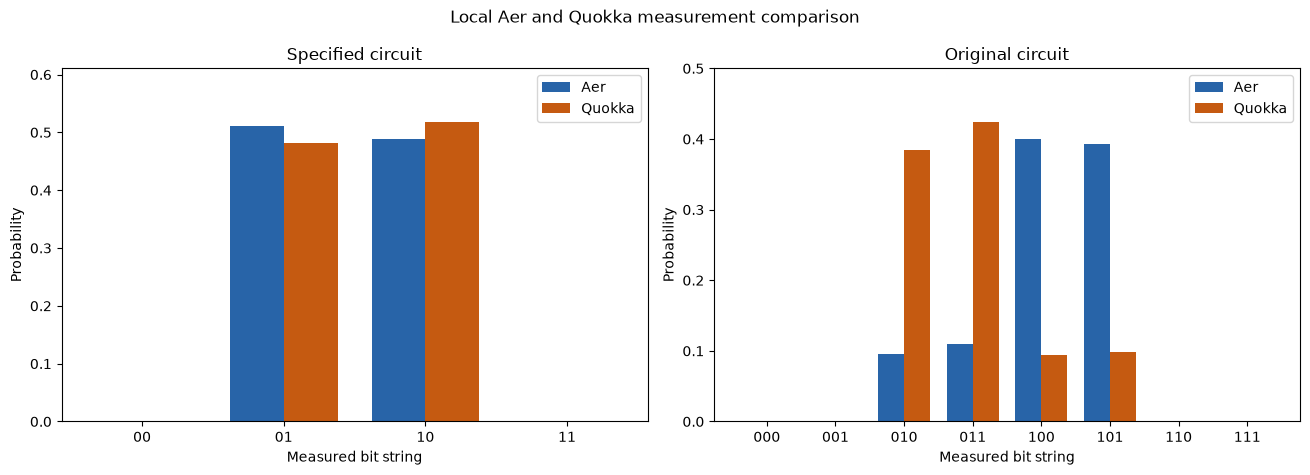

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
width = 0.38

for ax, labels, local_p, quokka_p, title in [
    (axes[0], specified_labels, specified_local_p, specified_quokka_p, "Specified circuit"),
    (axes[1], custom_labels, custom_local_p, custom_quokka_p, "Original circuit"),
]:
    positions = np.arange(len(labels))
    ax.bar(positions - width / 2, local_p, width, label="Aer", color="#2864A8")
    ax.bar(positions + width / 2, quokka_p, width, label="Quokka", color="#C55A11")
    ax.set_xticks(positions, labels)
    ax.set(title=title, xlabel="Measured bit string", ylabel="Probability")
    ax.set_ylim(0, max(float(local_p.max()), float(quokka_p.max())) * 1.18)
    ax.legend()

fig.suptitle("Local Aer and Quokka measurement comparison")
fig.tight_layout()
fig.savefig("task2_aer_quokka_comparison.png", dpi=180)
plt.show()


### 6.1 Specified circuit

Aer produced `01=524, 10=500`; Quokka produced `01=494, 10=530`. Both backends returned only the two theoretically valid anti-correlated states. The total variation distance (TVD) is 0.0293, a small difference for two independent 1024-shot samples. This supports the interpretation of `C` as CNOT and confirms correct measurement on Quokka.

### 6.2 Original circuit

Both backends returned the same support set (`010`, `011`, `100`, `101`) and no other states. However, Aer assigned about 79% probability to the q1=0 branch (`100`/`101`), whereas Quokka assigned about 81% to q1=1 (`010`/`011`). The TVD is approximately 0.59, far too large to attribute to finite-shot noise.

The unchanged support indicates that initialization, measurement wiring, and both CX relationships are being recognized. The probability inversion appears only in the branch affected by the RY-RZ-H sequence, so the most plausible explanation is a rotation/phase convention or QASM translation difference between Aer and the Quokka backend. This is an inference, not a proven root cause. A controlled calibration experiment that tests RY, RZ, and H separately would be required to isolate it. The actual device result is retained without alteration.


## 7. Conclusion

The specified Qiskit circuit and the original three-qubit QASM circuit were both generated, validated locally, and executed successfully on Quokka. The specified circuit produced the expected anti-correlated output on both systems. The original circuit demonstrated multiple gate types and exposed a substantive backend difference in rotation/phase behavior; reporting and quantifying this discrepancy provides stronger engineering evidence than assuming all simulators share identical gate conventions.


## References

[1] IBM Quantum, "Quantum circuit model," 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/api/qiskit/circuit (accessed 24 July 2026).  
[2] IBM Quantum, "Work with OpenQASM 2," 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/guides/interoperate-qiskit-qasm2 (accessed 24 July 2026).  
[3] Quokka Quantum, "Quokka Puck technical specifications," 2026. [Online]. Available: https://www.quokkacomputing.com/product-page/quokka-puck (accessed 24 July 2026).
